# Notebook14 v2 — Dynamic State Trajectories with Process Actions and Reward

---

## Goal of Notebook14 v2

Notebook14 v1 introduced dynamic cellular state trajectories.

Notebook14 v2 improves that model by adding three important upgrades:

1. normalized productivity state
2. multiple process intervention actions
3. reward function for future RL-style optimization

The purpose is to move from:

state → fixed transition → trajectory

toward:

state → action → transition → reward → trajectory

This is the foundation for future reinforcement learning and closed-loop process optimization.

---

## Why this matters

Real CHO bioprocess development is dynamic.

A clone does not simply have one fixed productivity or quality state.

Instead, over culture progression:

- burden can accumulate
- ER stress can increase
- oxidative stress can change
- glycosylation can drift
- productivity can collapse or recover
- process interventions can rescue or worsen outcomes

Notebook14 v2 simulates these dynamic responses.

---

## What is new compared with Notebook14 v1?

### 1. Productivity normalization

In Notebook14 v1, productivity_signal was not scaled to the same 0–1 range as burden, stress, and glycosylation variables.

Notebook14 v2 creates:

productivity_state

This makes dynamic simulation numerically more consistent.

---

### 2. Multiple process actions

Notebook14 v2 introduces several biologically motivated interventions:

- no_action
- adaptive_feed
- mild_temp_shift
- perfusion_rescue
- stress_mitigation

Each action affects the cellular state differently.

---

### 3. Reward function

Notebook14 v2 introduces a reward score.

The reward increases when:

- productivity is high
- glycosylation quality is high
- burden is low
- failure risk is low
- overflow burden is low

This creates the first bridge toward reinforcement learning.

---

## Important interpretation

Notebook14 v2 is still not full RL.

It is an RL-ready simulation layer.

A real RL notebook will later use this environment to learn which action to choose at each time point.

Notebook14 v2 prepares the environment for that next step.

## Section 1 — Import libraries

This section loads libraries for:

- data handling
- trajectory simulation
- plotting
- PCA
- clustering

In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

## Section 2 — Load Notebook13 multi-omics output

Notebook14 v2 starts from the multi-omics latent state dataset generated by Notebook13.

This dataset contains:

- productivity signal
- burden states
- stress states
- glycosylation state
- cellular archetype
- multi-omics latent features

These serve as the starting biological states for trajectory simulation.

In [2]:
# --------------------------------------------------
# Section 2 — Load Notebook13 output
# --------------------------------------------------

def find_project_root(start=None):
    if start is None:
        start = Path.cwd().resolve()

    start = Path(start).resolve()

    for p in [start, *start.parents]:
        if (p / "data" / "synthetic").exists():
            return p

    raise FileNotFoundError("Could not find project root containing data/synthetic")


ROOT = find_project_root()

scenario = "legacy"
n_clones = 5000

INPUT_PATH = (
    ROOT
    / "data"
    / "synthetic"
    / "omics"
    / f"notebook13_multiomics_latent_state_{n_clones}_{scenario}.csv"
)

df = pd.read_csv(INPUT_PATH)

print("ROOT:", ROOT)
print("INPUT_PATH:", INPUT_PATH)
print("df shape:", df.shape)

display(df.head())

ROOT: /Users/sang/CLD_ML_PIPELINE
INPUT_PATH: /Users/sang/CLD_ML_PIPELINE/data/synthetic/omics/notebook13_multiomics_latent_state_5000_legacy.csv
df shape: (92, 93)


,clone_id,process_condition,pareto_rank,candidate_archetype,weighted_multiobj_score,obj_productivity,obj_stability,obj_quality,obj_risk_safety,obj_rescue_value,...,met_nutrient_pressure,met_overflow_burden,omics_latent_1,omics_latent_2,omics_latent_3,omics_latent_4,cellular_state,cellular_archetype,tsne_1,tsne_2
0,CLONE_4625,stress_minimized,1.0,Rescue-value,0.832599,1.000000,0.830653,0.698502,0.612287,1.000000,...,0.518487,0.555266,4.402637,-0.910681,-0.404721,3.186541,0,Quality-Adapted,7.685490,-7.108506
1,CLONE_4878,stress_minimized,2.0,Balanced,0.730900,0.796817,0.692042,0.663813,0.731984,0.776958,...,0.393058,0.366546,2.675861,-2.601021,1.133786,1.362528,0,Quality-Adapted,5.410643,-1.035339
2,CLONE_3895,mild_temp_shift,3.0,Risk-safe,0.603442,0.011834,0.822675,0.986077,1.000000,0.388383,...,0.144979,0.099176,-4.845263,0.200871,0.349792,0.838802,3,Balanced-Resilient,-0.692288,8.589075
3,CLONE_3895,balanced_feed,4.0,Quality-led,0.601918,0.011834,0.822675,0.989642,0.983893,0.388383,...,0.145543,0.128355,-4.768517,0.790040,-1.619075,1.681215,3,Balanced-Resilient,-0.509352,9.235153
4,CLONE_3007,stress_minimized,5.0,Stability-led,0.601847,0.000540,0.992249,0.926534,0.967398,0.264918,...,0.162880,0.117508,-2.388811,-0.813747,-2.461280,-1.025476,3,Balanced-Resilient,2.135555,4.627896


## Section 3 — Validate required columns

This section confirms that all variables needed for dynamic simulation are present.

The key biological state variables are:

- productivity_signal
- integrated_burden
- oxidative_stress
- ER stress burden
- failure risk
- glycosylation state
- overflow burden
- rescue potential
- cellular archetype

In [3]:
# --------------------------------------------------
# Section 3 — Validate required columns
# --------------------------------------------------

required_cols = [
    "productivity_signal",
    "integrated_burden",
    "oxidative_stress",
    "er_stress_burden",
    "stress_failure_risk",
    "process_galactosylation_level",
    "process_sialylation_capacity",
    "met_overflow_burden",
    "rescue_potential_score",
    "cellular_archetype",
]

missing_cols = [c for c in required_cols if c not in df.columns]

if missing_cols:
    raise KeyError(f"Missing required columns: {missing_cols}")

print("All required columns are available.")

display(df[required_cols].describe(include="all"))

All required columns are available.


,productivity_signal,integrated_burden,oxidative_stress,er_stress_burden,stress_failure_risk,process_galactosylation_level,process_sialylation_capacity,met_overflow_burden,rescue_potential_score,cellular_archetype
count,9.200000e+01,92.000000,92.000000,92.000000,92.000000,92.000000,92.000000,92.000000,92.000000,92
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Quality-Adapted
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,75
mean,3.727049e-07,0.304636,0.341646,0.324108,0.320337,0.705708,0.660519,0.278334,0.604857,NaN
std,7.524082e-07,0.102507,0.115686,0.134248,0.123528,0.186275,0.204430,0.109755,0.071143,NaN
min,2.498445e-08,0.056264,0.065446,0.000000,0.000000,0.250485,0.288012,0.009155,0.425795,NaN
25%,8.950082e-08,0.221207,0.264259,0.232144,0.244631,0.596822,0.470016,0.197772,0.558909,NaN
50%,1.937304e-07,0.308754,0.342485,0.321828,0.318254,0.723012,0.652346,0.282303,0.607900,NaN
75%,3.636152e-07,0.380547,0.429701,0.429851,0.403930,0.840422,0.804557,0.352445,0.652658,NaN


## Section 4 — Normalize productivity state

Notebook14 v1 used raw productivity_signal directly.

However, productivity_signal is much smaller in numerical scale than burden, stress, and glycosylation variables.

Notebook14 v2 creates:

productivity_state

This variable rescales productivity_signal into a 0–1 range.

This makes it suitable for dynamic state simulation.

Raw productivity_signal:


count    9.200000e+01
mean     3.727049e-07
std      7.524082e-07
min      2.498445e-08
25%      8.950082e-08
50%      1.937304e-07
75%      3.636152e-07
max      5.537450e-06
Name: productivity_signal, dtype: float64

Normalized productivity_state:


count    92.000000
mean      0.063079
std       0.136492
min       0.000000
25%       0.011704
50%       0.030612
75%       0.061430
max       1.000000
Name: productivity_state, dtype: float64

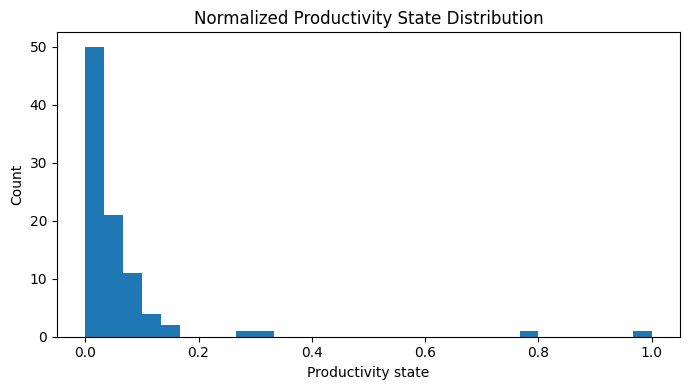

In [4]:
# --------------------------------------------------
# Section 4 — Normalize productivity signal
# --------------------------------------------------

prod_raw = df["productivity_signal"].astype(float)

df["productivity_state"] = (
    (prod_raw - prod_raw.min())
    / (prod_raw.max() - prod_raw.min() + 1e-12)
)

print("Raw productivity_signal:")
display(prod_raw.describe())

print("Normalized productivity_state:")
display(df["productivity_state"].describe())

plt.figure(figsize=(7, 4))
plt.hist(df["productivity_state"], bins=30)
plt.xlabel("Productivity state")
plt.ylabel("Count")
plt.title("Normalized Productivity State Distribution")
plt.tight_layout()
plt.show()

## Section 5 — Define process actions

This section defines process intervention actions.

These actions are simplified abstractions of real upstream process strategies.

Actions:

- no_action: continue current process
- adaptive_feed: improve nutrient supply and productivity, but may increase overflow burden
- mild_temp_shift: reduce ER stress and improve glycosylation, but may slightly reduce productivity
- perfusion_rescue: reduce overflow/metabolite burden and failure risk
- stress_mitigation: reduce oxidative and ER stress

These actions are not yet optimized by RL.

They are manually simulated to create an RL-ready environment.

In [5]:
# --------------------------------------------------
# Section 5 — Define process actions
# --------------------------------------------------

ACTIONS = [
    "no_action",
    "adaptive_feed",
    "mild_temp_shift",
    "perfusion_rescue",
    "stress_mitigation",
]

action_description = pd.DataFrame({
    "action": ACTIONS,
    "biological_meaning": [
        "Continue current process without intervention",
        "Increase nutrient support and productivity but may increase overflow",
        "Lower temperature-like effect: reduce ER stress and improve glycosylation, slight productivity tradeoff",
        "Perfusion-like rescue: reduce overflow burden and failure risk",
        "Stress relief intervention: reduce oxidative and ER stress",
    ]
})

display(action_description)

,action,biological_meaning
0,no_action,Continue current process without intervention
1,adaptive_feed,Increase nutrient support and productivity but...
2,mild_temp_shift,Lower temperature-like effect: reduce ER stres...
3,perfusion_rescue,Perfusion-like rescue: reduce overflow burden ...
4,stress_mitigation,Stress relief intervention: reduce oxidative a...


## Section 6 — Define transition function

This section defines how a cellular state changes over one pseudo-time step.

The transition function receives:

- current cellular state
- selected action
- biological rescue potential
- stochastic noise

and returns the next cellular state.

This is the key step that converts the notebook into an action-dependent dynamic simulator.

In [6]:
# --------------------------------------------------
# Section 6 — Transition function
# --------------------------------------------------

def apply_action_effects(
    action,
    prod,
    burden,
    ox,
    er,
    risk,
    gal,
    sia,
    overflow,
):
    """
    Apply direct action effects to cellular state variables.
    All values are expected to be on approximately 0-1 scale.
    """

    if action == "no_action":
        pass

    elif action == "adaptive_feed":
        # Nutrient support improves productivity,
        # but excessive feeding can increase overflow burden.
        prod += 0.035
        overflow += 0.025
        burden += 0.010

    elif action == "mild_temp_shift":
        # Mild temperature shift reduces ER stress and improves glycosylation,
        # but may slightly reduce productivity.
        prod -= 0.015
        er -= 0.045
        ox -= 0.015
        gal += 0.035
        sia += 0.025
        risk -= 0.020

    elif action == "perfusion_rescue":
        # Perfusion-like rescue removes metabolites and stabilizes process risk.
        overflow -= 0.070
        burden -= 0.050
        risk -= 0.045
        ox -= 0.020

    elif action == "stress_mitigation":
        # Stress mitigation reduces oxidative and ER burden.
        ox -= 0.060
        er -= 0.060
        risk -= 0.030
        gal += 0.015

    else:
        raise ValueError(f"Unknown action: {action}")

    return (
        np.clip(prod, 0, 1),
        np.clip(burden, 0, 1),
        np.clip(ox, 0, 1),
        np.clip(er, 0, 1),
        np.clip(risk, 0, 1),
        np.clip(gal, 0, 1),
        np.clip(sia, 0, 1),
        np.clip(overflow, 0, 1),
    )


def transition_step(
    prod,
    burden,
    ox,
    er,
    risk,
    gal,
    sia,
    overflow,
    rescue,
    action,
    rng,
):
    """
    One-step dynamic transition.
    """

    adaptive_capacity = (
        0.50 * rescue
        + 0.25 * (1 - burden)
        + 0.25 * (1 - risk)
    )

    # Natural biological drift before action
    burden_delta = (
        0.035 * prod
        + 0.045 * overflow
        - 0.050 * adaptive_capacity
        + rng.normal(0, 0.015)
    )

    stress_delta = (
        0.050 * burden
        + 0.030 * overflow
        - 0.040 * rescue
        + rng.normal(0, 0.015)
    )

    productivity_delta = (
        -0.050 * burden
        -0.035 * risk
        + 0.040 * rescue
        + rng.normal(0, 0.020)
    )

    glycan_delta = (
        -0.030 * er
        -0.020 * ox
        + 0.030 * rescue
        + rng.normal(0, 0.010)
    )

    overflow_delta = (
        0.035 * burden
        + 0.025 * prod
        - 0.030 * rescue
        + rng.normal(0, 0.012)
    )

    risk_delta = (
        0.050 * burden
        + 0.030 * er
        + 0.020 * ox
        - 0.045 * rescue
        + rng.normal(0, 0.012)
    )

    prod = np.clip(prod + productivity_delta, 0, 1)
    burden = np.clip(burden + burden_delta, 0, 1)
    ox = np.clip(ox + stress_delta, 0, 1)
    er = np.clip(er + stress_delta, 0, 1)
    gal = np.clip(gal + glycan_delta, 0, 1)
    sia = np.clip(sia + glycan_delta, 0, 1)
    overflow = np.clip(overflow + overflow_delta, 0, 1)
    risk = np.clip(risk + risk_delta, 0, 1)

    # Apply process action effects
    (
        prod,
        burden,
        ox,
        er,
        risk,
        gal,
        sia,
        overflow,
    ) = apply_action_effects(
        action,
        prod,
        burden,
        ox,
        er,
        risk,
        gal,
        sia,
        overflow,
    )

    return {
        "productivity_state": prod,
        "integrated_burden": burden,
        "oxidative_stress": ox,
        "er_stress_burden": er,
        "stress_failure_risk": risk,
        "galactosylation": gal,
        "sialylation": sia,
        "overflow_burden": overflow,
    }

## Section 7 — Define reward function

This section defines what the simulator considers a good cellular state.

The reward increases with:

- productivity
- galactosylation
- sialylation
- low burden
- low failure risk
- low overflow burden

This reward does not yet train an RL agent.

However, it provides the mathematical objective that future RL will optimize.

In [7]:
# --------------------------------------------------
# Section 7 — Reward function
# --------------------------------------------------

def compute_reward(
    prod,
    burden,
    risk,
    gal,
    sia,
    overflow,
):
    """
    Reward function for future RL-style optimization.

    Higher reward means better manufacturing state.
    """

    reward = (
        0.30 * prod
        + 0.20 * gal
        + 0.15 * sia
        - 0.15 * burden
        - 0.12 * risk
        - 0.08 * overflow
    )

    return reward

## Section 8 — Define action policies

This section defines simple rule-based policies.

These are not RL agents yet.

They are manually defined strategies used to compare how different interventions affect trajectories.

Policies:

- no_action_policy
- adaptive_feed_policy
- temp_shift_policy
- perfusion_policy
- stress_mitigation_policy
- rule_based_policy

The rule_based_policy chooses actions depending on the current state.

In [8]:
# --------------------------------------------------
# Section 8 — Policy functions
# --------------------------------------------------

def no_action_policy(state, t):
    return "no_action"


def adaptive_feed_policy(state, t):
    if t >= 4:
        return "adaptive_feed"
    return "no_action"


def temp_shift_policy(state, t):
    if t >= 5:
        return "mild_temp_shift"
    return "no_action"


def perfusion_policy(state, t):
    if t >= 5:
        return "perfusion_rescue"
    return "no_action"


def stress_mitigation_policy(state, t):
    if t >= 5:
        return "stress_mitigation"
    return "no_action"


def rule_based_policy(state, t):
    """
    Simple state-dependent process policy.

    This approximates a human process scientist choosing interventions
    based on observed burden and stress.
    """

    if state["overflow_burden"] > 0.45 or state["integrated_burden"] > 0.45:
        return "perfusion_rescue"

    if state["er_stress_burden"] > 0.45 or state["oxidative_stress"] > 0.45:
        return "stress_mitigation"

    if state["galactosylation"] < 0.60 and t >= 5:
        return "mild_temp_shift"

    if state["productivity_state"] < 0.45 and state["integrated_burden"] < 0.35:
        return "adaptive_feed"

    return "no_action"


POLICIES = {
    "no_action": no_action_policy,
    "adaptive_feed": adaptive_feed_policy,
    "mild_temp_shift": temp_shift_policy,
    "perfusion_rescue": perfusion_policy,
    "stress_mitigation": stress_mitigation_policy,
    "rule_based": rule_based_policy,
}

print("Available policies:")
for k in POLICIES:
    print("-", k)

Available policies:
- no_action
- adaptive_feed
- mild_temp_shift
- perfusion_rescue
- stress_mitigation
- rule_based


## Section 9 — Simulate trajectories under all policies

This section simulates each clone-process candidate under multiple process policies.

For each candidate and policy, the notebook records:

- pseudo-time
- action selected
- state variables
- reward
- cellular archetype

This creates an RL-ready trajectory table.

In [9]:
# --------------------------------------------------
# Section 9 — Simulate trajectories under policies
# --------------------------------------------------

rng = np.random.default_rng(42)

n_steps = 15

records = []

for policy_name, policy_func in POLICIES.items():

    for idx, row in df.iterrows():

        state = {
            "productivity_state": float(row["productivity_state"]),
            "integrated_burden": float(row["integrated_burden"]),
            "oxidative_stress": float(row["oxidative_stress"]),
            "er_stress_burden": float(row["er_stress_burden"]),
            "stress_failure_risk": float(row["stress_failure_risk"]),
            "galactosylation": float(row["process_galactosylation_level"]),
            "sialylation": float(row["process_sialylation_capacity"]),
            "overflow_burden": float(row["met_overflow_burden"]),
            "rescue_potential": float(row["rescue_potential_score"]),
        }

        for t in range(n_steps):

            action = policy_func(state, t)

            next_state = transition_step(
                prod=state["productivity_state"],
                burden=state["integrated_burden"],
                ox=state["oxidative_stress"],
                er=state["er_stress_burden"],
                risk=state["stress_failure_risk"],
                gal=state["galactosylation"],
                sia=state["sialylation"],
                overflow=state["overflow_burden"],
                rescue=state["rescue_potential"],
                action=action,
                rng=rng,
            )

            reward = compute_reward(
                prod=next_state["productivity_state"],
                burden=next_state["integrated_burden"],
                risk=next_state["stress_failure_risk"],
                gal=next_state["galactosylation"],
                sia=next_state["sialylation"],
                overflow=next_state["overflow_burden"],
            )

            records.append({
                "clone_process_id": idx,
                "policy": policy_name,
                "pseudo_time": t,
                "action": action,
                "cellular_archetype": row["cellular_archetype"],
                "rescue_potential": state["rescue_potential"],
                **next_state,
                "reward": reward,
            })

            state.update(next_state)

trajectory_v2 = pd.DataFrame(records)

print("trajectory_v2 shape:", trajectory_v2.shape)

display(trajectory_v2.head())

trajectory_v2 shape: (8280, 15)


,clone_process_id,policy,pseudo_time,action,cellular_archetype,rescue_potential,productivity_state,integrated_burden,oxidative_stress,er_stress_burden,stress_failure_risk,galactosylation,sialylation,overflow_burden,reward
0,0,no_action,0,no_action,Quality-Adapted,0.584229,0.995759,0.591557,0.376073,0.673473,0.439010,0.768677,0.645732,0.558729,0.363210
1,0,no_action,1,no_action,Quality-Adapted,0.584229,0.973849,0.626745,0.394300,0.691700,0.479357,0.749948,0.627002,0.597353,0.336872
2,0,no_action,2,no_action,Quality-Adapted,0.584229,0.958454,0.662922,0.437097,0.734498,0.501534,0.730245,0.607299,0.630533,0.314615
3,0,no_action,3,no_action,Quality-Adapted,0.584229,0.927426,0.712968,0.465041,0.762442,0.537312,0.710185,0.587240,0.674841,0.282941
4,0,no_action,4,no_action,Quality-Adapted,0.584229,0.906987,0.745394,0.492284,0.789684,0.584014,0.699193,0.576247,0.710406,0.259648


## Section 10 — Check action usage

This section checks how often each action was selected.

This is especially useful for the rule-based policy because actions are chosen dynamically based on the cellular state.

In [10]:
# --------------------------------------------------
# Section 10 — Action usage summary
# --------------------------------------------------

action_usage = (
    trajectory_v2
    .groupby(["policy", "action"])
    .size()
    .reset_index(name="count")
)

display(action_usage)

policy_action_pivot = (
    action_usage
    .pivot(index="policy", columns="action", values="count")
    .fillna(0)
    .astype(int)
)

display(policy_action_pivot)

,policy,action,count
0,adaptive_feed,adaptive_feed,1012
1,adaptive_feed,no_action,368
2,mild_temp_shift,mild_temp_shift,920
3,mild_temp_shift,no_action,460
4,no_action,no_action,1380
5,perfusion_rescue,no_action,460
6,perfusion_rescue,perfusion_rescue,920
7,rule_based,adaptive_feed,834
8,rule_based,mild_temp_shift,86
9,rule_based,no_action,286


action,adaptive_feed,mild_temp_shift,no_action,perfusion_rescue,stress_mitigation
policy,,,,,
adaptive_feed,1012,0,368,0,0
mild_temp_shift,0,920,460,0,0
no_action,0,0,1380,0,0
perfusion_rescue,0,0,460,920,0
rule_based,834,86,286,91,83
stress_mitigation,0,0,460,0,920


## Section 11 — Compare policy-level reward

This section compares average reward across policies.

A better policy should have:

- higher reward
- lower burden
- lower failure risk
- better quality preservation

,reward,productivity_state,integrated_burden,stress_failure_risk,galactosylation,sialylation,overflow_burden
policy,,,,,,,
rule_based,0.232,0.252,0.234,0.287,0.753,0.688,0.344
perfusion_rescue,0.231,0.121,0.115,0.209,0.723,0.678,0.115
mild_temp_shift,0.219,0.071,0.190,0.271,0.817,0.752,0.225
stress_mitigation,0.216,0.104,0.184,0.237,0.778,0.688,0.218
adaptive_feed,0.207,0.222,0.238,0.342,0.717,0.671,0.339
no_action,0.188,0.094,0.185,0.331,0.720,0.672,0.221


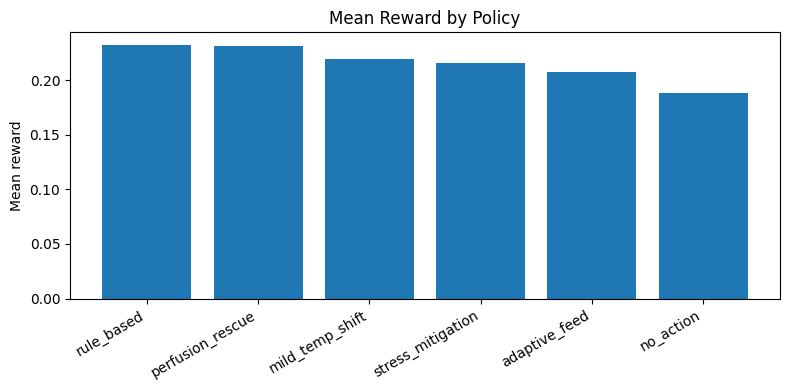

In [11]:
# --------------------------------------------------
# Section 11 — Policy reward comparison
# --------------------------------------------------

policy_summary = (
    trajectory_v2
    .groupby("policy")[
        [
            "reward",
            "productivity_state",
            "integrated_burden",
            "stress_failure_risk",
            "galactosylation",
            "sialylation",
            "overflow_burden",
        ]
    ]
    .mean()
    .round(3)
    .sort_values("reward", ascending=False)
)

display(policy_summary)

plt.figure(figsize=(8, 4))
plt.bar(policy_summary.index, policy_summary["reward"])
plt.ylabel("Mean reward")
plt.title("Mean Reward by Policy")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

## Section 12 — Visualize average trajectory by policy

This section compares how different policies affect dynamic trajectories.

The plots show policy-level average behavior for:

- reward
- productivity
- burden
- failure risk
- galactosylation

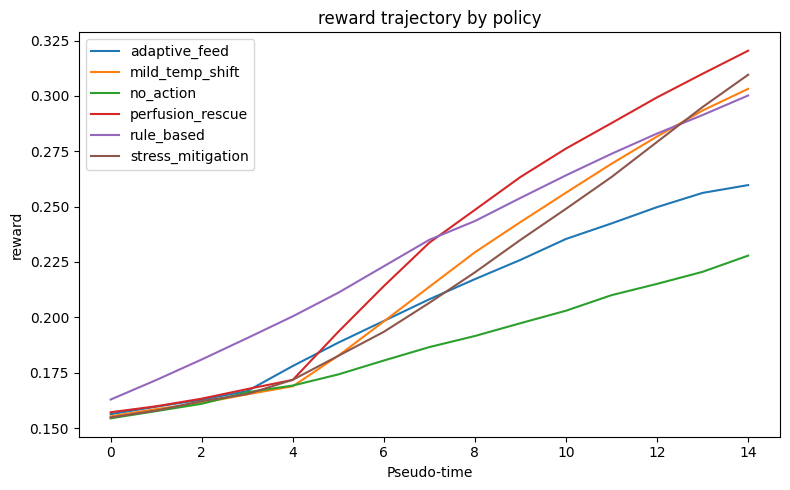

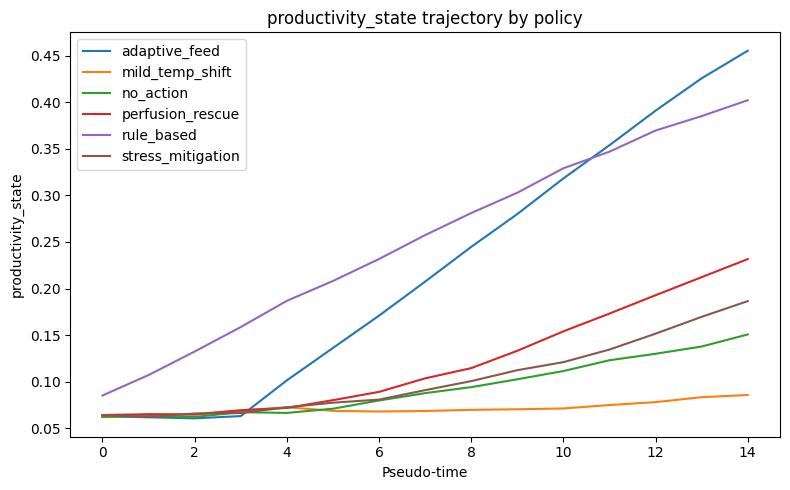

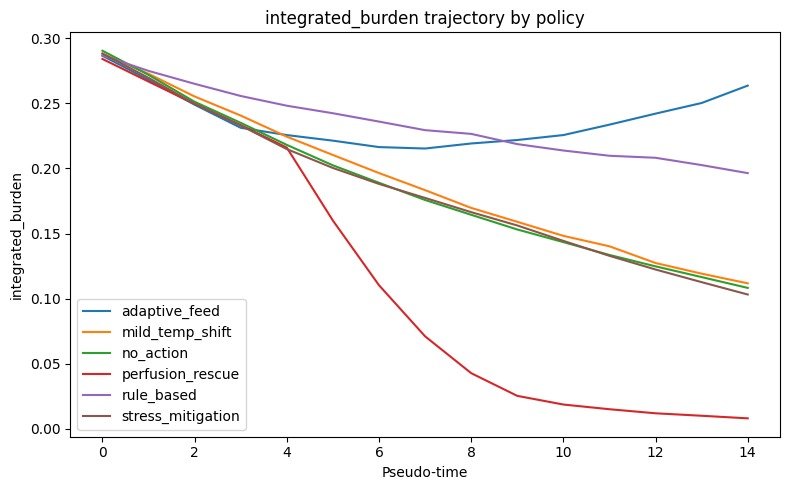

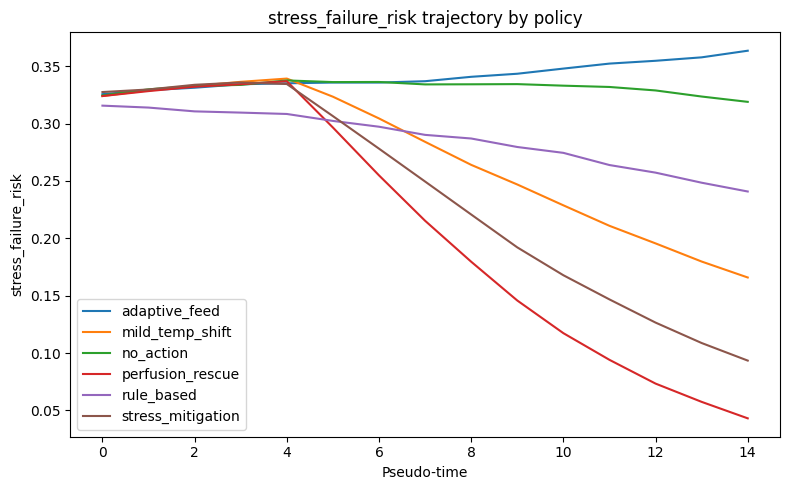

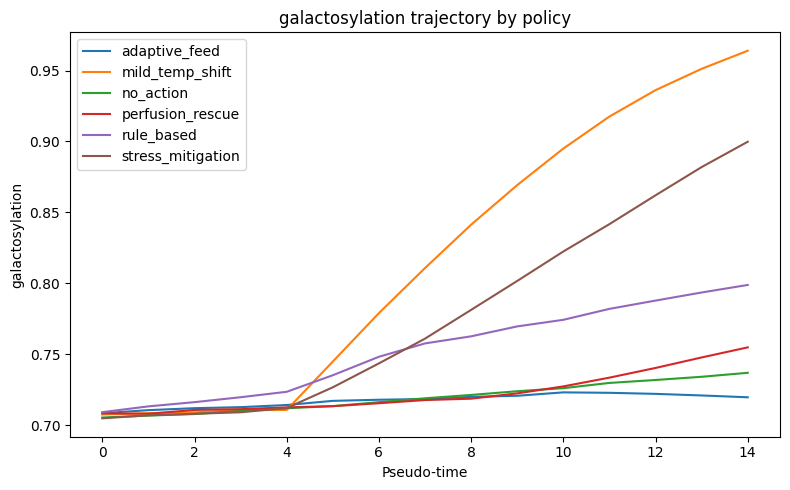

In [12]:
# --------------------------------------------------
# Section 12 — Average trajectories by policy
# --------------------------------------------------

avg_policy_traj = (
    trajectory_v2
    .groupby(["policy", "pseudo_time"])[
        [
            "reward",
            "productivity_state",
            "integrated_burden",
            "stress_failure_risk",
            "galactosylation",
        ]
    ]
    .mean()
    .reset_index()
)

for metric in [
    "reward",
    "productivity_state",
    "integrated_burden",
    "stress_failure_risk",
    "galactosylation",
]:

    plt.figure(figsize=(8, 5))

    for policy in avg_policy_traj["policy"].unique():
        subset = avg_policy_traj[avg_policy_traj["policy"] == policy]

        plt.plot(
            subset["pseudo_time"],
            subset[metric],
            label=policy
        )

    plt.xlabel("Pseudo-time")
    plt.ylabel(metric)
    plt.title(f"{metric} trajectory by policy")
    plt.legend()
    plt.tight_layout()
    plt.show()

## Section 13 — Final state comparison

This section compares the final pseudo-time state for each policy.

This approximates endpoint process performance.

The final state is important because real process development often evaluates final culture outcome.

In [13]:
# --------------------------------------------------
# Section 13 — Final state comparison
# --------------------------------------------------

final_state = (
    trajectory_v2
    .sort_values("pseudo_time")
    .groupby(["policy", "clone_process_id"])
    .tail(1)
)

final_policy_summary = (
    final_state
    .groupby("policy")[
        [
            "reward",
            "productivity_state",
            "integrated_burden",
            "stress_failure_risk",
            "galactosylation",
            "sialylation",
            "overflow_burden",
        ]
    ]
    .mean()
    .round(3)
    .sort_values("reward", ascending=False)
)

display(final_policy_summary)

,reward,productivity_state,integrated_burden,stress_failure_risk,galactosylation,sialylation,overflow_burden
policy,,,,,,,
perfusion_rescue,0.320,0.232,0.008,0.043,0.755,0.710,0.002
stress_mitigation,0.310,0.187,0.103,0.093,0.900,0.756,0.163
mild_temp_shift,0.303,0.086,0.112,0.166,0.964,0.899,0.168
rule_based,0.300,0.402,0.196,0.241,0.799,0.720,0.374
adaptive_feed,0.260,0.455,0.264,0.364,0.720,0.671,0.478
no_action,0.228,0.151,0.108,0.319,0.737,0.688,0.169


## Section 14 — Dynamic latent-state compression

This section compresses the dynamic trajectory table into a 2D latent state space using PCA.

This allows us to visualize how different policies move cellular states through dynamic biological space.

In [14]:
# --------------------------------------------------
# Section 14 — Dynamic latent-state compression
# --------------------------------------------------

latent_cols = [
    "productivity_state",
    "integrated_burden",
    "oxidative_stress",
    "er_stress_burden",
    "stress_failure_risk",
    "galactosylation",
    "sialylation",
    "overflow_burden",
    "reward",
]

scaler = StandardScaler()
X = scaler.fit_transform(trajectory_v2[latent_cols])

pca = PCA(n_components=2)
latent = pca.fit_transform(X)

trajectory_v2["dynamic_latent_1"] = latent[:, 0]
trajectory_v2["dynamic_latent_2"] = latent[:, 1]

print("Explained variance ratio:")
print(pca.explained_variance_ratio_)

Explained variance ratio:
[0.58277374 0.1507309 ]


## Section 15 — Visualize dynamic latent space

This plot shows the dynamic cellular-state landscape.

Each point represents a clone-process-policy-time state.

Color indicates pseudo-time.

This helps determine whether cellular states move systematically through pseudo-time.

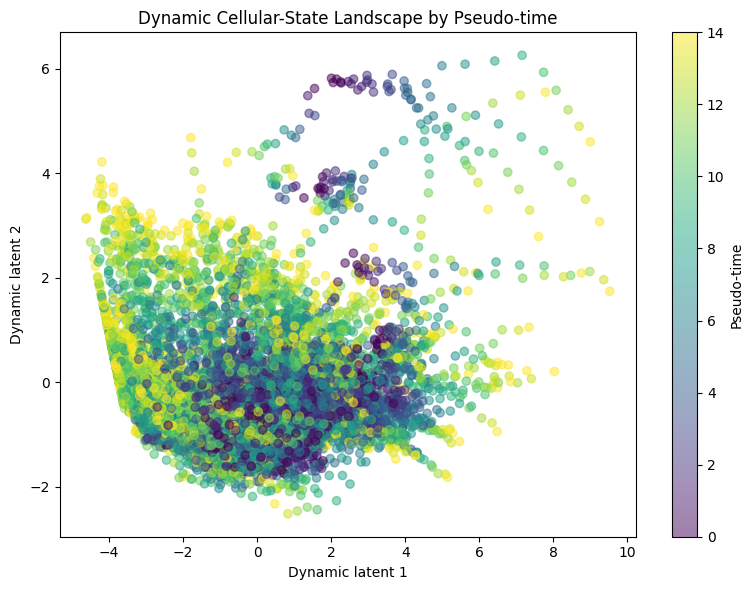

In [15]:
# --------------------------------------------------
# Section 15 — Dynamic latent-space visualization
# --------------------------------------------------

plt.figure(figsize=(8, 6))

scatter = plt.scatter(
    trajectory_v2["dynamic_latent_1"],
    trajectory_v2["dynamic_latent_2"],
    c=trajectory_v2["pseudo_time"],
    alpha=0.5
)

plt.xlabel("Dynamic latent 1")
plt.ylabel("Dynamic latent 2")
plt.title("Dynamic Cellular-State Landscape by Pseudo-time")
plt.colorbar(scatter, label="Pseudo-time")
plt.tight_layout()
plt.show()

## Section 16 — Dynamic regime clustering

This section clusters trajectory states into dynamic regimes.

Each regime represents a recurring biological state pattern, such as:

- productive/rescued
- stressed/high-risk
- adaptive/intermediate
- burdened/low-quality

In [16]:
# --------------------------------------------------
# Section 16 — Dynamic regime clustering + regime names
# --------------------------------------------------

kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

trajectory_v2["dynamic_regime"] = kmeans.fit_predict(
    trajectory_v2[
        [
            "dynamic_latent_1",
            "dynamic_latent_2",
        ]
    ]
)

# Human-readable regime labels based on Section 17 interpretation
regime_names = {
    0: "Adaptive_Quality",
    1: "Stress_HighRisk",
    2: "Productive_Rescued",
    3: "Burdened_LowQuality",
}

trajectory_v2["regime_name"] = (
    trajectory_v2["dynamic_regime"]
    .map(regime_names)
)

display(
    trajectory_v2[
        [
            "dynamic_regime",
            "regime_name",
        ]
    ]
    .drop_duplicates()
    .sort_values("dynamic_regime")
    .reset_index(drop=True)
)

display(
    trajectory_v2["regime_name"]
    .value_counts()
)

,dynamic_regime,regime_name
0,0,Adaptive_Quality
1,1,Stress_HighRisk
2,2,Productive_Rescued
3,3,Burdened_LowQuality


regime_name
Burdened_LowQuality    3180
Adaptive_Quality       2469
Productive_Rescued     1994
Stress_HighRisk         637
Name: count, dtype: int64

## Section 16b — Visualize dynamic regimes in latent space

This plot shows the four dynamic regimes in the PCA-derived dynamic latent space.

Each point is one simulated clone-process-policy-time state.

The color indicates the assigned dynamic regime.

This helps confirm whether the regimes occupy distinct regions of the dynamic cellular-state landscape.

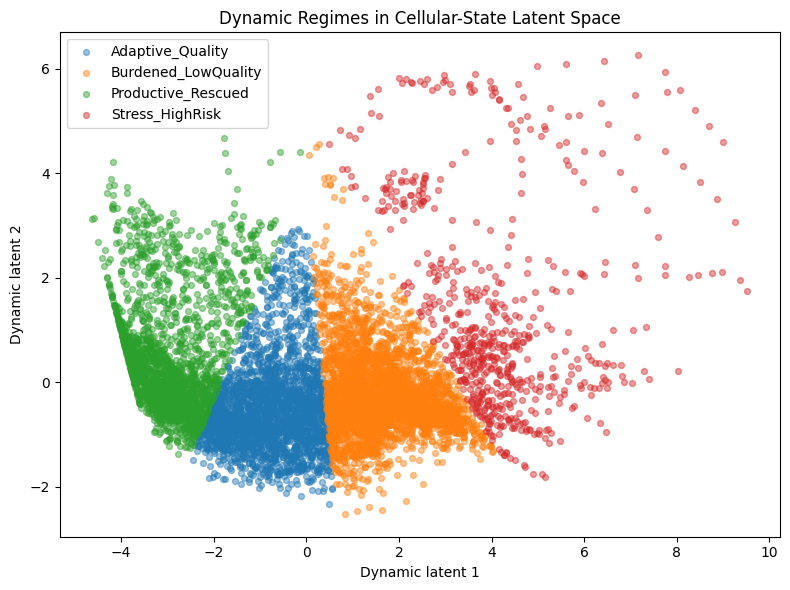

In [17]:
# --------------------------------------------------
# Section 16b — Visualize dynamic regimes in latent space
# --------------------------------------------------

plt.figure(figsize=(8, 6))

for regime_name in sorted(trajectory_v2["regime_name"].unique()):
    subset = trajectory_v2[
        trajectory_v2["regime_name"] == regime_name
    ]

    plt.scatter(
        subset["dynamic_latent_1"],
        subset["dynamic_latent_2"],
        label=regime_name,
        alpha=0.45,
        s=18
    )

plt.xlabel("Dynamic latent 1")
plt.ylabel("Dynamic latent 2")
plt.title("Dynamic Regimes in Cellular-State Latent Space")
plt.legend()
plt.tight_layout()
plt.show()

## Section 17 — Characterize dynamic regimes

This section summarizes each dynamic regime.

This helps interpret what each cluster means biologically.

In [18]:
# --------------------------------------------------
# Section 17 — Named dynamic regime characterization
# --------------------------------------------------

regime_summary = (
    trajectory_v2
    .groupby("regime_name")[
        [
            "reward",
            "productivity_state",
            "integrated_burden",
            "stress_failure_risk",
            "galactosylation",
            "sialylation",
            "overflow_burden",
        ]
    ]
    .mean()
    .round(3)
    .sort_values("reward", ascending=False)
)

display(regime_summary)

,reward,productivity_state,integrated_burden,stress_failure_risk,galactosylation,sialylation,overflow_burden
regime_name,,,,,,,
Productive_Rescued,0.366,0.258,0.024,0.040,0.881,0.860,0.099
Adaptive_Quality,0.230,0.097,0.111,0.210,0.769,0.687,0.174
Burdened_LowQuality,0.136,0.080,0.290,0.415,0.694,0.615,0.327
Stress_HighRisk,0.085,0.287,0.529,0.620,0.562,0.562,0.549


## Section 18 — Policy distribution across regimes

This section checks which policies produce which dynamic regimes.

A useful policy should produce more high-reward, low-burden regimes.

In [19]:
# --------------------------------------------------
# Section 18 — Policy distribution across named dynamic regimes
# --------------------------------------------------

policy_regime = (
    trajectory_v2
    .groupby(["policy", "regime_name"])
    .size()
    .reset_index(name="count")
)

policy_regime_pivot = (
    policy_regime
    .pivot(
        index="policy",
        columns="regime_name",
        values="count"
    )
    .fillna(0)
    .astype(int)
)

# Optional: order columns by biological interpretation
preferred_order = [
    "Productive_Rescued",
    "Adaptive_Quality",
    "Burdened_LowQuality",
    "Stress_HighRisk",
]

existing_order = [
    c for c in preferred_order
    if c in policy_regime_pivot.columns
]

policy_regime_pivot = policy_regime_pivot[existing_order]

display(policy_regime_pivot)

regime_name,Productive_Rescued,Adaptive_Quality,Burdened_LowQuality,Stress_HighRisk
policy,,,,
adaptive_feed,299,295,527,259
mild_temp_shift,355,454,482,89
no_action,257,425,566,132
perfusion_rescue,393,529,400,58
rule_based,272,317,773,18
stress_mitigation,418,449,432,81


## Section 19 — Export Notebook14 v2 outputs

This section exports the dynamic trajectory dataset and summaries.

These outputs are useful for future Notebook15 RL-style policy optimization.

In [20]:
# --------------------------------------------------
# Section 19 — Export outputs
# --------------------------------------------------

OUT_DIR = (
    ROOT
    / "data"
    / "synthetic"
    / "digital_twin"
)

OUT_DIR.mkdir(parents=True, exist_ok=True)

TRAJ_PATH = (
    OUT_DIR
    / f"notebook14_v2_dynamic_policy_trajectory_{n_clones}_{scenario}.csv"
)

POLICY_SUMMARY_PATH = (
    OUT_DIR
    / f"notebook14_v2_policy_summary_{n_clones}_{scenario}.csv"
)

FINAL_POLICY_SUMMARY_PATH = (
    OUT_DIR
    / f"notebook14_v2_final_policy_summary_{n_clones}_{scenario}.csv"
)

REGIME_SUMMARY_PATH = (
    OUT_DIR
    / f"notebook14_v2_dynamic_regime_summary_{n_clones}_{scenario}.csv"
)

trajectory_v2.to_csv(TRAJ_PATH, index=False)
policy_summary.to_csv(POLICY_SUMMARY_PATH)
final_policy_summary.to_csv(FINAL_POLICY_SUMMARY_PATH)
regime_summary.to_csv(REGIME_SUMMARY_PATH)

print("Saved:")
print(TRAJ_PATH)
print(POLICY_SUMMARY_PATH)
print(FINAL_POLICY_SUMMARY_PATH)
print(REGIME_SUMMARY_PATH)

Saved:
/Users/sang/CLD_ML_PIPELINE/data/synthetic/digital_twin/notebook14_v2_dynamic_policy_trajectory_5000_legacy.csv
/Users/sang/CLD_ML_PIPELINE/data/synthetic/digital_twin/notebook14_v2_policy_summary_5000_legacy.csv
/Users/sang/CLD_ML_PIPELINE/data/synthetic/digital_twin/notebook14_v2_final_policy_summary_5000_legacy.csv
/Users/sang/CLD_ML_PIPELINE/data/synthetic/digital_twin/notebook14_v2_dynamic_regime_summary_5000_legacy.csv


# Final Summary — Notebook14 v2

Notebook14 v2 upgraded the dynamic cellular-state simulator.

Notebook14 v1 introduced:

state → trajectory

Notebook14 v2 introduced:

state → action → transition → reward → trajectory

This is a major step toward future reinforcement learning and closed-loop process optimization.

---

## Major improvements

Notebook14 v2 added:

1. normalized productivity state
2. multiple process intervention actions
3. action-dependent transition function
4. reward function
5. rule-based policy simulation
6. policy comparison
7. dynamic latent-state compression
8. dynamic regime discovery

---

## Biological meaning

The simulator now approximates how process actions alter CHO cellular states over time.

For example:

- adaptive feeding can improve productivity but may increase overflow burden
- mild temperature shift can reduce ER stress and improve glycosylation
- perfusion rescue can reduce metabolite burden and failure risk
- stress mitigation can reduce oxidative and ER stress

This creates a biologically meaningful dynamic control framework.

---

## What this notebook shows

Notebook14 v2 evaluates whether different process policies can maintain better cellular states over pseudo-time.

A successful policy should show:

- higher reward
- higher productivity
- better glycosylation
- lower burden
- lower failure risk
- lower overflow burden

This helps identify process-control strategies that could improve manufacturability.

---

## Relationship to RL

Notebook14 v2 is not full reinforcement learning yet.

However, it creates the essential components required for RL:

- state
- action
- transition
- reward
- trajectory

Notebook15 can now use these components to test simple RL-style or policy-learning approaches.

---

## Strategic significance

Notebook14 v2 moves the project closer to a dynamic CHO-cell digital twin.

The simulator is now able to represent:

clone-process state
→ process action
→ biological response
→ reward
→ next state

This is the conceptual foundation for:

- closed-loop process optimization
- self-driving laboratory simulation
- RL-guided upstream process development
- autonomous biologics manufacturing intelligence

---

## Important limitation

The action effects and reward function are still synthetic and heuristic.

They are biologically motivated but not yet experimentally calibrated.

Future work should calibrate action effects using:

- real fed-batch data
- perfusion datasets
- time-course metabolomics
- glycosylation time-course data
- NISTCHO or other CHO reference datasets
- internal CDMO/CLD experimental data

---

## Next step

If Notebook14 v2 outputs are coherent, the next notebook should be:

Notebook15 — RL-ready Policy Optimization Prototype

Notebook15 can use the state-action-reward-transition structure created here to test simple RL or policy-search logic.